# Midterm Take-home Exam

## Background

In previous semesters, I used an single attendance quiz to track  attendance in each course.  Students took multiple attempts of the same quiz, one at the start of each class. Consequently, the number of attempts a student took on this quiz represents the number of class sessions that student attended.

In some, but not all, of my courses I also provide practice quizzes that students can use to prepare for actual quizzes and tests.  These quizzes pull questions randomly from a bank of questions, allow students unlimited attempts, and are not used as part of the students grade.

For this part of the exam, you will collect simulated data from mock classes into one table, then and create a summarize table.

## Assessment Overview

When evaluating your work, here is what I will generally be looking for.

* **Path/file/table management.** All file paths should be discovered via `glob` and relevant information should be extracted using regular expressions. All path data and individual tables should then processed using comprehensions.

* **Data management.** All data management should be performed using `polars` dot-chains.
* **Clean code.** Use appropriate names that relate to the context of the problem.  Refactor complicated expressions using `lambda` helper functions.
* **Notebook management.** Your final notebook should include proper organization and comments and be easy to navigate via a table of contents.

## File structure

The files found in `attendance_example` folder contains (made-up and random) examples of the D2L files that I use to summarize my attendance quizzes and practice quizzes.  Note that there is important information that you need to extract from the file path. 


<div>
 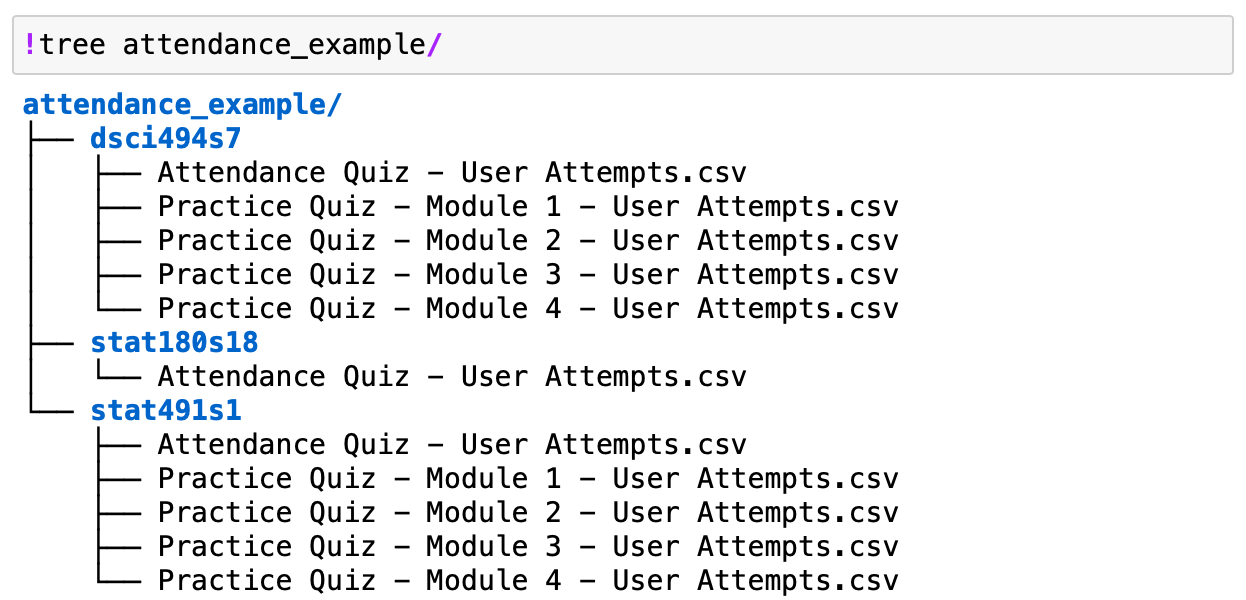
</div>

### Task 1 - Combine the attendance data

<div>
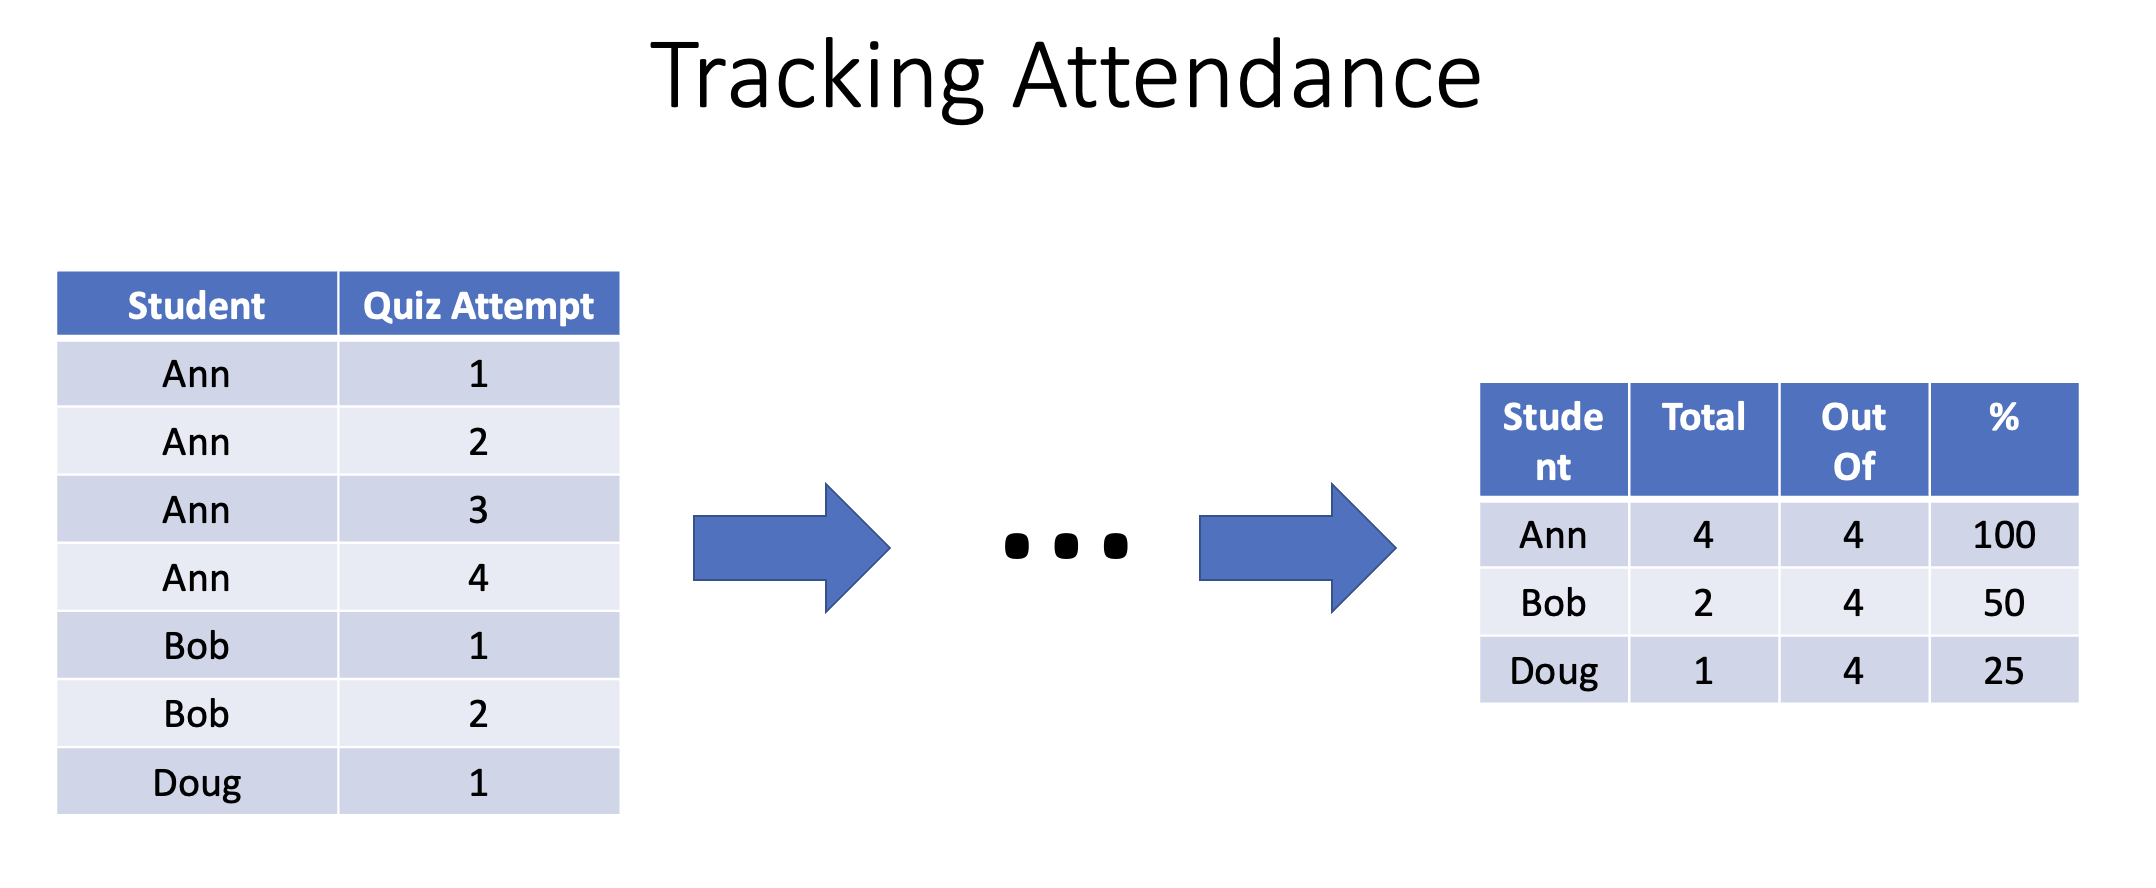
</div>

Your first task is to combine the attendance data for all courses into a table with the following columns.
* `Program` (e.g., `stat`)
* `Course` (e.g., `491`)
* `Section` (e.g., `s1`)
* `UserName`
* `FirstName`
* `LastName`
* `TotalAttendance` (number of classes attended)
* `OutOf` (total possible number of classes, assume this is the same as the maximum over all students in the same course)
* `PercentAttendance`
    
Write this table to a CSV file name `combined_attendance.csv`.

### Notes to Navigate the Notebook and Find my Results

I saved my final csv-files and visualizations for each problem in a folder called 'results' which is placed in my root folder.

### Import Statements/Loading Libraries

In [102]:
import polars as pl
from glob import glob
import re
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import MaxNLocator, ScalarFormatter
import polars.selectors as cs

### Reading in Files

In [103]:
attendance_files = glob('./attendance_example/*/Attendance Quiz - User Attempts.csv')
attendance_files

['./attendance_example\\dsci494s7\\Attendance Quiz - User Attempts.csv',
 './attendance_example\\stat180s18\\Attendance Quiz - User Attempts.csv',
 './attendance_example\\stat491s1\\Attendance Quiz - User Attempts.csv']

In [104]:
attendance_by_class = [pl.read_csv(f) for f in attendance_files]
attendance_by_class

[shape: (674, 10)
 ┌─────────────┬──────────┬───────────┬──────────┬───┬────────┬─────────────┬─────────────┬─────────┐
 │ Org Defined ┆ UserName ┆ FirstName ┆ LastName ┆ … ┆ Out Of ┆ Attempt_Sta ┆ Attempt_End ┆ Percent │
 │ ID          ┆ ---      ┆ ---       ┆ ---      ┆   ┆ ---    ┆ rt          ┆ ---         ┆ ---     │
 │ ---         ┆ str      ┆ str       ┆ str      ┆   ┆ i64    ┆ ---         ┆ str         ┆ str     │
 │ i64         ┆          ┆           ┆          ┆   ┆        ┆ str         ┆             ┆         │
 ╞═════════════╪══════════╪═══════════╪══════════╪═══╪════════╪═════════════╪═════════════╪═════════╡
 │ 14460432    ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ 1      ┆ 2019-01-14  ┆ 2019-01-14  ┆ 100 %   │
 │             ┆          ┆           ┆          ┆   ┆        ┆ 14:00:00    ┆ 14:06:00    ┆         │
 │ 14460432    ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ 1      ┆ 2019-01-16  ┆ 2019-01-16  ┆ 100 %   │
 │             ┆          ┆           ┆          ┆   ┆        ┆ 

### Extracting Program, Course, and Section Information

#### WET Method:

In [105]:
program_re = re.compile(r'^\./attendance_example\\([a-z]{4})\d{3}[a-z]\d{1,2}\\Attendance Quiz - User Attempts.csv')
get_program = lambda p: program_re.match(p).group(1) if program_re.match(p) else None

program_names = [get_program(file) for file in attendance_files]
program_names

['dsci', 'stat', 'stat']

In [106]:
course_re = re.compile(r'^\./attendance_example\\[a-z]{4}(\d{3})[a-z]\d{1,2}\\Attendance Quiz - User Attempts.csv')
get_course = lambda c: course_re.match(c).group(1) if course_re.match(c) else None

course_names = [get_course(file) for file in attendance_files]
course_names

['494', '180', '491']

In [107]:
section_re = re.compile(r'^\./attendance_example\\[a-z]{4}\d{3}([a-z]\d{1,2})\\Attendance Quiz - User Attempts.csv')
get_section = lambda s: section_re.match(s).group(1) if section_re.match(s) else None

section_names = [get_section(file) for file in attendance_files]
section_names

['s7', 's18', 's1']

#### Now combine the logic of the last three cells to make it follow the DRY principle:

In [108]:
pattern = re.compile(r'^\./attendance_example\\([a-z]{4})(\d{3})([a-z]\d{1,2})\\Attendance Quiz - User Attempts.csv')
extract_info = lambda p: pattern.match(p).groups() if pattern.match(p) else (None, None, None)
info = [extract_info(file) for file in attendance_files]
program, course, section = zip(*info)
program, course, section

(('dsci', 'stat', 'stat'), ('494', '180', '491'), ('s7', 's18', 's1'))

### Combine the Information and Tables and Create Appropriate Columns

In [109]:
attendance_by_program_course_section = [(*extract_info(f), pl.read_csv(f)) for f in attendance_files]
attendance_by_program_course_section

[('dsci',
  '494',
  's7',
  shape: (674, 10)
  ┌─────────────┬──────────┬───────────┬──────────┬───┬────────┬─────────────┬─────────────┬─────────┐
  │ Org Defined ┆ UserName ┆ FirstName ┆ LastName ┆ … ┆ Out Of ┆ Attempt_Sta ┆ Attempt_End ┆ Percent │
  │ ID          ┆ ---      ┆ ---       ┆ ---      ┆   ┆ ---    ┆ rt          ┆ ---         ┆ ---     │
  │ ---         ┆ str      ┆ str       ┆ str      ┆   ┆ i64    ┆ ---         ┆ str         ┆ str     │
  │ i64         ┆          ┆           ┆          ┆   ┆        ┆ str         ┆             ┆         │
  ╞═════════════╪══════════╪═══════════╪══════════╪═══╪════════╪═════════════╪═════════════╪═════════╡
  │ 14460432    ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ 1      ┆ 2019-01-14  ┆ 2019-01-14  ┆ 100 %   │
  │             ┆          ┆           ┆          ┆   ┆        ┆ 14:00:00    ┆ 14:06:00    ┆         │
  │ 14460432    ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ 1      ┆ 2019-01-16  ┆ 2019-01-16  ┆ 100 %   │
  │             ┆          

In [110]:
attendance_files_with_class_info = [df.with_columns(
        pl.lit(program).alias("Program"),
        pl.lit(course).alias("Course"),
        pl.lit(section).alias("Section"))
    for program, course, section, df in attendance_by_program_course_section]
attendance_files_with_class_info

[shape: (674, 13)
 ┌────────────────┬──────────┬───────────┬──────────┬───┬─────────┬─────────┬────────┬─────────┐
 │ Org Defined ID ┆ UserName ┆ FirstName ┆ LastName ┆ … ┆ Percent ┆ Program ┆ Course ┆ Section │
 │ ---            ┆ ---      ┆ ---       ┆ ---      ┆   ┆ ---     ┆ ---     ┆ ---    ┆ ---     │
 │ i64            ┆ str      ┆ str       ┆ str      ┆   ┆ str     ┆ str     ┆ str    ┆ str     │
 ╞════════════════╪══════════╪═══════════╪══════════╪═══╪═════════╪═════════╪════════╪═════════╡
 │ 14460432       ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ 100 %   ┆ dsci    ┆ 494    ┆ s7      │
 │ 14460432       ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ 100 %   ┆ dsci    ┆ 494    ┆ s7      │
 │ 14460432       ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ 100 %   ┆ dsci    ┆ 494    ┆ s7      │
 │ 14460432       ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ 100 %   ┆ dsci    ┆ 494    ┆ s7      │
 │ 14460432       ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ 100 %   ┆ dsci    ┆ 494    ┆ s7      │
 │ …        

### Combine Files

In [111]:
combined_attendance_files = pl.concat(attendance_files_with_class_info)
combined_attendance_files

Org Defined ID,UserName,FirstName,LastName,Attempt #,Score,Out Of,Attempt_Start,Attempt_End,Percent,Program,Course,Section
i64,str,str,str,i64,i64,i64,str,str,str,str,str,str
14460432,"""au9747cp""","""Jericho""","""Greer""",1,1,1,"""2019-01-14 14:00:00""","""2019-01-14 14:06:00""","""100 %""","""dsci""","""494""","""s7"""
14460432,"""au9747cp""","""Jericho""","""Greer""",2,1,1,"""2019-01-16 14:00:00""","""2019-01-16 14:08:00""","""100 %""","""dsci""","""494""","""s7"""
14460432,"""au9747cp""","""Jericho""","""Greer""",3,1,1,"""2019-01-18 14:00:00""","""2019-01-18 14:05:00""","""100 %""","""dsci""","""494""","""s7"""
14460432,"""au9747cp""","""Jericho""","""Greer""",4,1,1,"""2019-01-23 14:00:00""","""2019-01-23 14:06:00""","""100 %""","""dsci""","""494""","""s7"""
14460432,"""au9747cp""","""Jericho""","""Greer""",5,1,1,"""2019-01-25 14:00:00""","""2019-01-25 14:10:00""","""100 %""","""dsci""","""494""","""s7"""
…,…,…,…,…,…,…,…,…,…,…,…,…
12630683,"""iv8164nd""","""Vinci""","""Alberich""",16,1,1,"""2019-03-04 11:01:00""","""2019-03-04 11:04:00""","""100 %""","""stat""","""491""","""s1"""
12630683,"""iv8164nd""","""Vinci""","""Alberich""",17,1,1,"""2019-03-06 11:58:00""","""2019-03-06 12:02:00""","""100 %""","""stat""","""491""","""s1"""
12630683,"""iv8164nd""","""Vinci""","""Alberich""",1,1,1,"""2019-01-14 11:03:00""","""2019-01-14 11:10:00""","""100 %""","""stat""","""491""","""s1"""


### Data Management - Preparing the Final Table

In [112]:
combined_files = (combined_attendance_files
                  .select(['Program', 'Course', 'Section', 'UserName', 'FirstName', 'LastName', "Attempt #"])
                  .group_by(cs.string())
                  .agg(pl.max("Attempt #").alias("TotalAttendance"))
                  .sort(['Program', 'Course', 'Section'])
                  .with_columns(OutOf = pl.col('TotalAttendance').max().over(['Program', 'Course', 'Section']))
                  .with_columns(PercentAttendance = pl.col('TotalAttendance')/pl.col('OutOf')*100)
                 )
combined_files

Program,Course,Section,UserName,FirstName,LastName,TotalAttendance,OutOf,PercentAttendance
str,str,str,str,str,str,i64,i64,f64
"""dsci""","""494""","""s7""","""yw2911sz""","""Philippine""","""Gaylord""",19,19,100.0
"""dsci""","""494""","""s7""","""ma3547fa""","""Goodyear""","""Cargill""",19,19,100.0
"""dsci""","""494""","""s7""","""au9747cp""","""Jericho""","""Greer""",18,19,94.736842
"""dsci""","""494""","""s7""","""ix1122ks""","""Merrimack""","""Hadrian""",14,19,73.684211
"""dsci""","""494""","""s7""","""qe3386ba""","""Willard""","""Kafka""",19,19,100.0
…,…,…,…,…,…,…,…,…
"""stat""","""491""","""s1""","""nz6014ah""","""Edmonds""","""Tuesday""",15,19,78.947368
"""stat""","""491""","""s1""","""kz3175av""","""Bergland""","""Italian""",18,19,94.736842
"""stat""","""491""","""s1""","""iq1062uy""","""Lang""","""O'Dell""",19,19,100.0


In [113]:
combined_files.write_csv('./results/combined_attendance.csv')

### Make a Visualization for the Problem

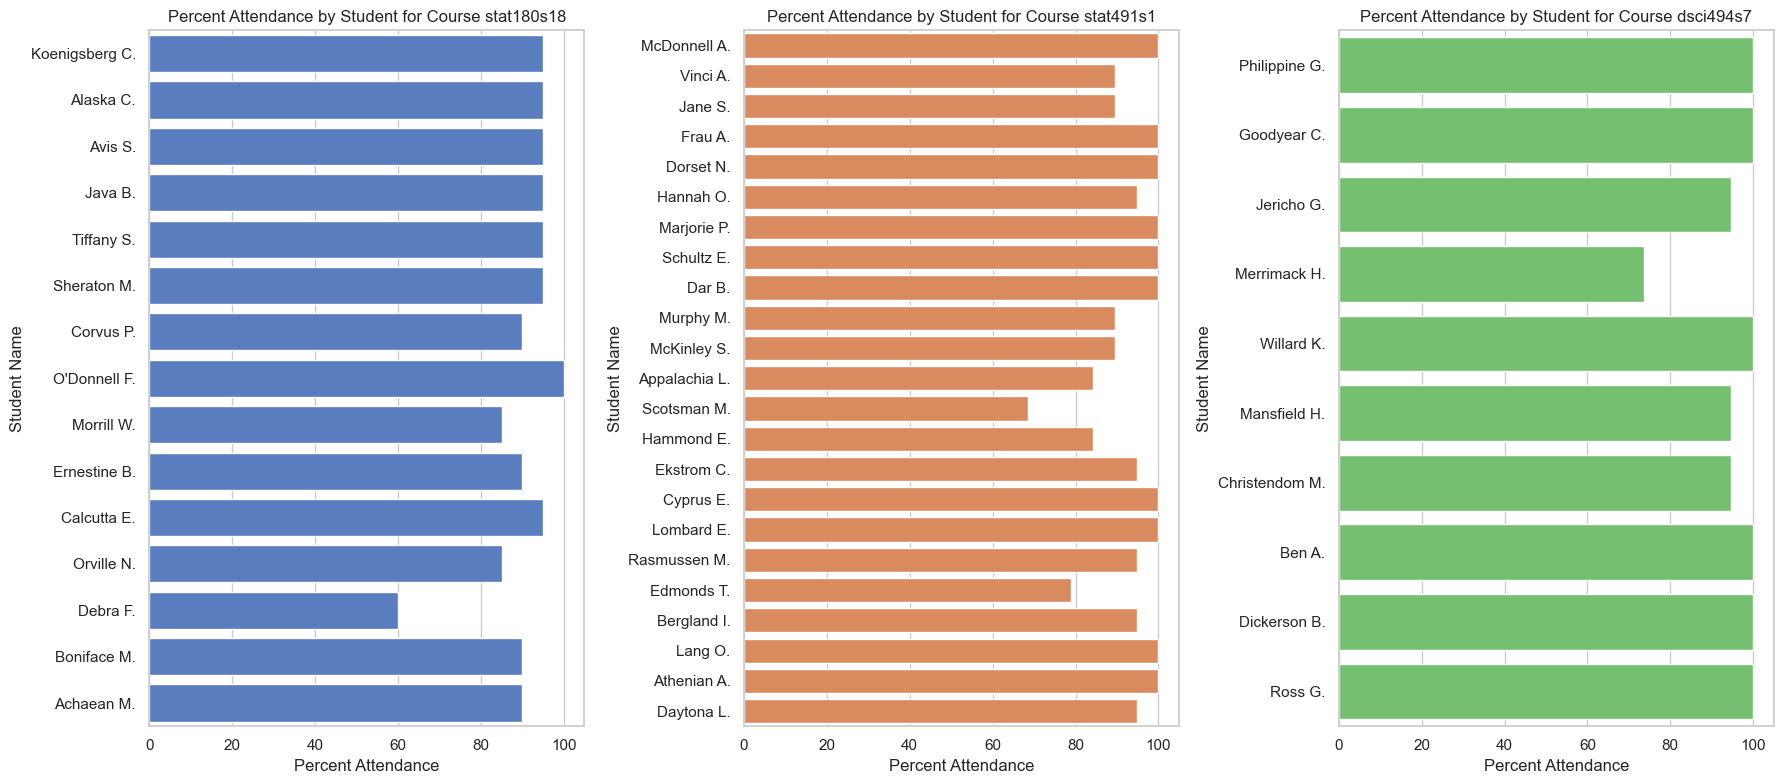

In [114]:
muted_palette = sns.color_palette("muted", 3) 
color_mapping = {
    's18': muted_palette[0], 
    's1': muted_palette[1],    
    's7': muted_palette[2]}
sections = ['s18', 's1', 's7'] 
n_sections = len(sections)
fig, axes = plt.subplots(1, n_sections, figsize=(18, 8))
sns.set(style="whitegrid")
for i, section in enumerate(sections):
    section_data = combined_files.filter(pl.col('Section') == section).to_pandas() 
    program = section_data['Program'].iloc[0] if not section_data.empty else "Unknown Program"
    course = section_data['Course'].iloc[0] if not section_data.empty else "Unknown Course"
    section_data['FullName'] = section_data['FirstName'] + ' ' + section_data['LastName'].str[0] + '.'
    color = color_mapping.get(section, 'gray') 
    sns.barplot(x='PercentAttendance', y='FullName', data=section_data, ax=axes[i], color=color)
    axes[i].set_title(f'Percent Attendance by Student for Course {program}{course}{section}')
    axes[i].set_xlabel('Percent Attendance')
    axes[i].set_ylabel('Student Name')
plt.tight_layout()
percent_attendance_by_student = fig
plt.show()

In [115]:
percent_attendance_by_student.savefig('./results/percent_attendance_by_student.png', dpi=72)

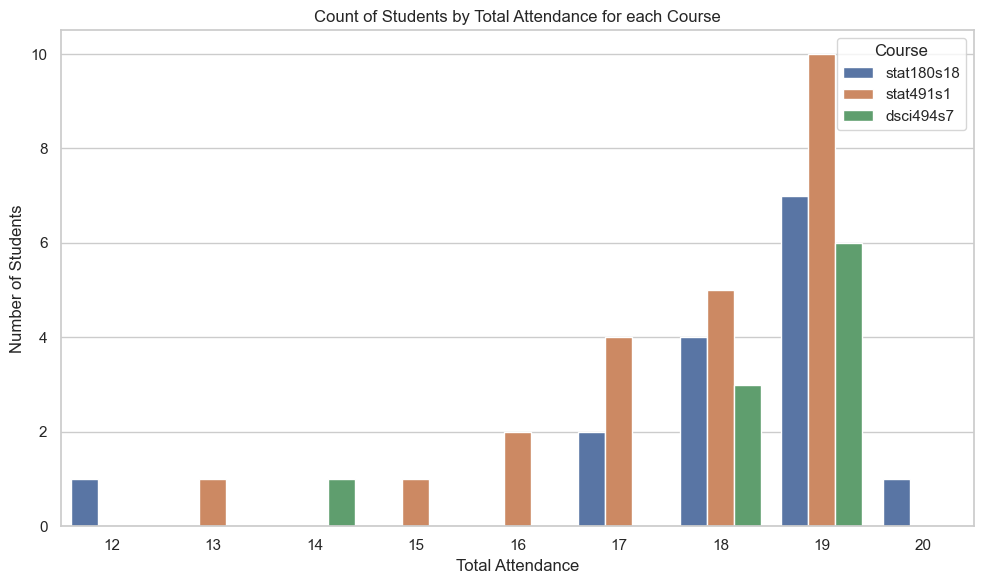

In [116]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
combined_files = combined_files.with_columns((pl.col('Program') + pl.col('Course') + pl.col('Section')).alias('ProgramCourseSection'))
sns.countplot(x='TotalAttendance', data=combined_files.to_pandas(), hue='ProgramCourseSection')
plt.title('Count of Students by Total Attendance for each Course')
plt.xlabel('Total Attendance')
plt.ylabel('Number of Students')
plt.legend(title='Course') 
plt.tight_layout()
count_students_by_attendance = plt.gcf()
plt.show()


In [117]:
count_students_by_attendance.savefig('./results/count_students_by_attendance.png', dpi=72)

### Task 2 - Combine the practice quiz data

<div>
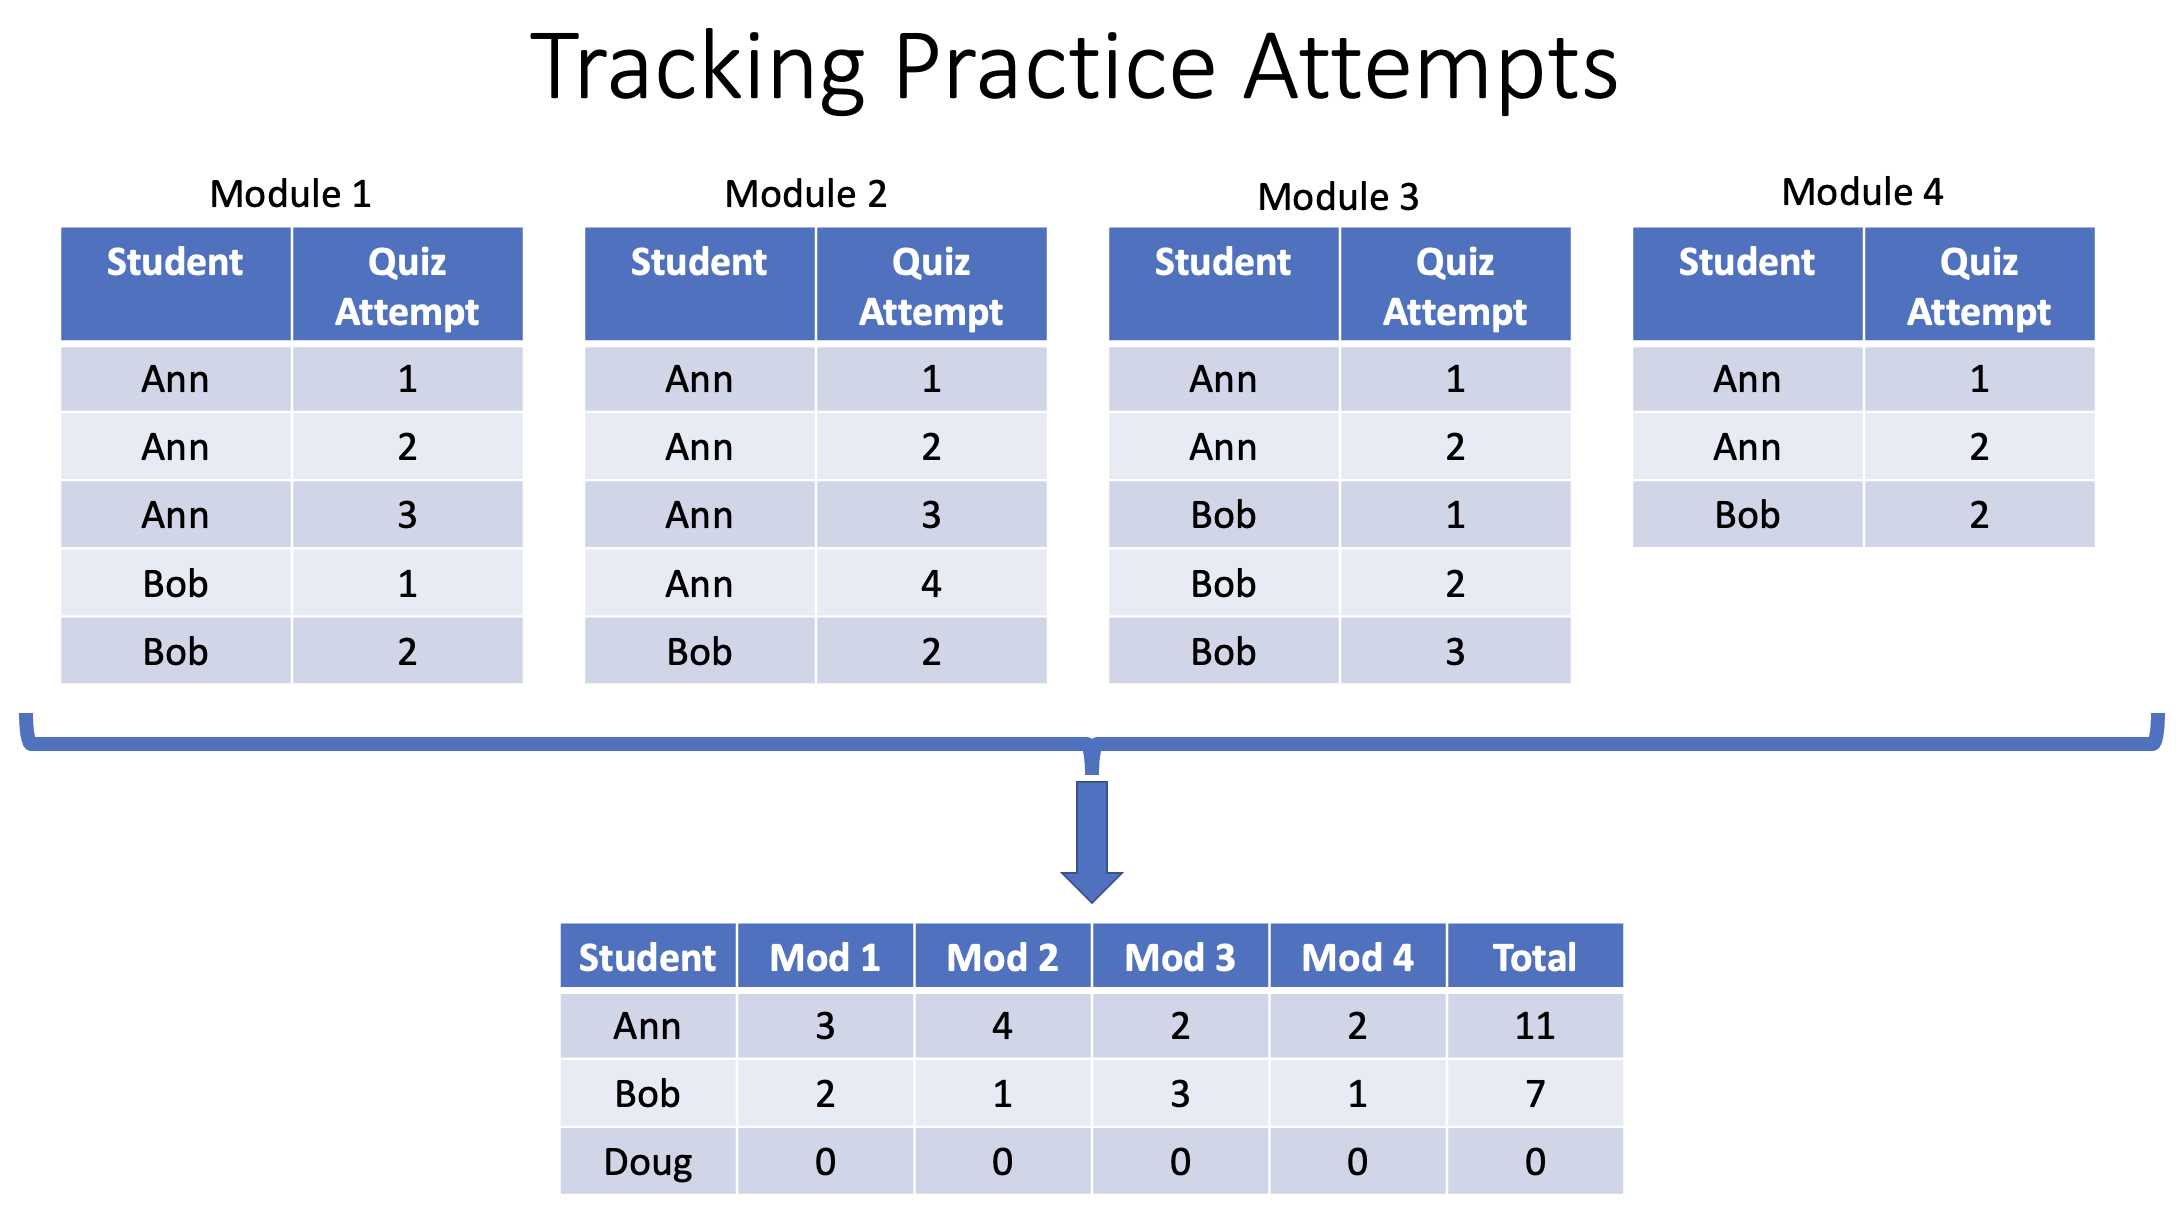
</div>

Some of the classes folders contain information about attempts on practice quizzes for each of four modules.  We want to create a single master table for all class that summarizes the practice quiz attempts.  This table should contain the following columns: 
* `Program` (e.g., `stat`)
* `Course` (e.g., `491`)
* `Section` (e.g., `s1`)
* `UserName`
* `FirstName`
* `LastName`
* `Module 1 Attempts`, 
* `Module 2 Attempts`, 
* `Module 3 Attempts`, 
* `Module 4 Attempts`, and 
* `Total Attempts`.  

Note that, for example, `Module 1 Attempts` contains the total number of attempts each student made on that corresponding quiz and `Total Attempts` contains the total number of attempts over all four quizzes.

Write this table to a CSV file named `combined_quiz_attempts.csv`.

### Reading in Files

In [118]:
quiz_files = glob('./attendance_example/*/Practice Quiz - *.csv')
quiz_files

['./attendance_example\\dsci494s7\\Practice Quiz - Module 1 - User Attempts.csv',
 './attendance_example\\dsci494s7\\Practice Quiz - Module 2 - User Attempts.csv',
 './attendance_example\\dsci494s7\\Practice Quiz - Module 3 - User Attempts.csv',
 './attendance_example\\dsci494s7\\Practice Quiz - Module 4 - User Attempts.csv',
 './attendance_example\\stat491s1\\Practice Quiz - Module 1 - User Attempts.csv',
 './attendance_example\\stat491s1\\Practice Quiz - Module 2 - User Attempts.csv',
 './attendance_example\\stat491s1\\Practice Quiz - Module 3 - User Attempts.csv',
 './attendance_example\\stat491s1\\Practice Quiz - Module 4 - User Attempts.csv']

In [119]:
quiz_by_class = [pl.read_csv(f) for f in quiz_files]
quiz_by_class

[shape: (316, 10)
 ┌─────────────┬──────────┬───────────┬──────────┬───┬────────┬─────────────┬─────────────┬─────────┐
 │ Org Defined ┆ UserName ┆ FirstName ┆ LastName ┆ … ┆ Out Of ┆ Attempt_Sta ┆ Attempt_End ┆ Percent │
 │ ID          ┆ ---      ┆ ---       ┆ ---      ┆   ┆ ---    ┆ rt          ┆ ---         ┆ ---     │
 │ ---         ┆ str      ┆ str       ┆ str      ┆   ┆ i64    ┆ ---         ┆ str         ┆ str     │
 │ i64         ┆          ┆           ┆          ┆   ┆        ┆ str         ┆             ┆         │
 ╞═════════════╪══════════╪═══════════╪══════════╪═══╪════════╪═════════════╪═════════════╪═════════╡
 │ 14460432    ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ 20     ┆ 2019-01-28  ┆ 2019-01-28  ┆ 50 %    │
 │             ┆          ┆           ┆          ┆   ┆        ┆ 15:26:00    ┆ 15:30:00    ┆         │
 │ 14460432    ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ 20     ┆ 2019-01-27  ┆ 2019-01-27  ┆ 95 %    │
 │             ┆          ┆           ┆          ┆   ┆        ┆ 

### Extracting Program, Course, Section, and Module Information

In [120]:
pattern = re.compile(r'^\./attendance_example\\([a-z]{4})(\d{3})([a-z]\d{1,2})\\Practice Quiz - Module (\d{1}) - User Attempts.csv')
extract_info = lambda p: pattern.match(p).groups() if pattern.match(p) else (None, None, None, None)
info = [extract_info(file) for file in quiz_files]
program, course, section, module = zip(*info)
program, course, section, module

(('dsci', 'dsci', 'dsci', 'dsci', 'stat', 'stat', 'stat', 'stat'),
 ('494', '494', '494', '494', '491', '491', '491', '491'),
 ('s7', 's7', 's7', 's7', 's1', 's1', 's1', 's1'),
 ('1', '2', '3', '4', '1', '2', '3', '4'))

### Combine the Information and Tables and Create Appropriate Columns

In [121]:
quiz_by_program_course_section = [(*extract_info(f), pl.read_csv(f)) for f in quiz_files]
quiz_by_program_course_section

[('dsci',
  '494',
  's7',
  '1',
  shape: (316, 10)
  ┌─────────────┬──────────┬───────────┬──────────┬───┬────────┬─────────────┬─────────────┬─────────┐
  │ Org Defined ┆ UserName ┆ FirstName ┆ LastName ┆ … ┆ Out Of ┆ Attempt_Sta ┆ Attempt_End ┆ Percent │
  │ ID          ┆ ---      ┆ ---       ┆ ---      ┆   ┆ ---    ┆ rt          ┆ ---         ┆ ---     │
  │ ---         ┆ str      ┆ str       ┆ str      ┆   ┆ i64    ┆ ---         ┆ str         ┆ str     │
  │ i64         ┆          ┆           ┆          ┆   ┆        ┆ str         ┆             ┆         │
  ╞═════════════╪══════════╪═══════════╪══════════╪═══╪════════╪═════════════╪═════════════╪═════════╡
  │ 14460432    ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ 20     ┆ 2019-01-28  ┆ 2019-01-28  ┆ 50 %    │
  │             ┆          ┆           ┆          ┆   ┆        ┆ 15:26:00    ┆ 15:30:00    ┆         │
  │ 14460432    ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ 20     ┆ 2019-01-27  ┆ 2019-01-27  ┆ 95 %    │
  │             ┆   

In [122]:
quiz_files_with_class_info = [df.with_columns(
        pl.lit(program).alias("Program"),
        pl.lit(course).alias("Course"),
        pl.lit(section).alias("Section"),
        pl.lit(module).alias("Module"))
    for program, course, section, module, df in quiz_by_program_course_section]
quiz_files_with_class_info

[shape: (316, 14)
 ┌────────────────┬──────────┬───────────┬──────────┬───┬─────────┬────────┬─────────┬────────┐
 │ Org Defined ID ┆ UserName ┆ FirstName ┆ LastName ┆ … ┆ Program ┆ Course ┆ Section ┆ Module │
 │ ---            ┆ ---      ┆ ---       ┆ ---      ┆   ┆ ---     ┆ ---    ┆ ---     ┆ ---    │
 │ i64            ┆ str      ┆ str       ┆ str      ┆   ┆ str     ┆ str    ┆ str     ┆ str    │
 ╞════════════════╪══════════╪═══════════╪══════════╪═══╪═════════╪════════╪═════════╪════════╡
 │ 14460432       ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ dsci    ┆ 494    ┆ s7      ┆ 1      │
 │ 14460432       ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ dsci    ┆ 494    ┆ s7      ┆ 1      │
 │ 14460432       ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ dsci    ┆ 494    ┆ s7      ┆ 1      │
 │ 14460432       ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ dsci    ┆ 494    ┆ s7      ┆ 1      │
 │ 14460432       ┆ au9747cp ┆ Jericho   ┆ Greer    ┆ … ┆ dsci    ┆ 494    ┆ s7      ┆ 1      │
 │ …              ┆ … 

### Combine Files

In [123]:
combined_quiz_files = pl.concat(quiz_files_with_class_info)
combined_quiz_files

Org Defined ID,UserName,FirstName,LastName,Attempt #,Score,Out Of,Attempt_Start,Attempt_End,Percent,Program,Course,Section,Module
i64,str,str,str,i64,i64,i64,str,str,str,str,str,str,str
14460432,"""au9747cp""","""Jericho""","""Greer""",1,10,20,"""2019-01-28 15:26:00""","""2019-01-28 15:30:00""","""50 %""","""dsci""","""494""","""s7""","""1"""
14460432,"""au9747cp""","""Jericho""","""Greer""",1,19,20,"""2019-01-27 15:25:00""","""2019-01-27 15:34:00""","""95 %""","""dsci""","""494""","""s7""","""1"""
14460432,"""au9747cp""","""Jericho""","""Greer""",2,11,20,"""2019-01-27 15:29:00""","""2019-01-27 15:33:00""","""55 %""","""dsci""","""494""","""s7""","""1"""
14460432,"""au9747cp""","""Jericho""","""Greer""",3,9,20,"""2019-01-27 15:37:00""","""2019-01-27 15:38:00""","""45 %""","""dsci""","""494""","""s7""","""1"""
14460432,"""au9747cp""","""Jericho""","""Greer""",4,3,20,"""2019-01-27 15:43:00""","""2019-01-27 15:49:00""","""15 %""","""dsci""","""494""","""s7""","""1"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
18630821,"""ct6978kd""","""Ekstrom""","""Czech""",6,11,20,"""2019-02-25 11:32:00""","""2019-02-25 11:35:00""","""55 %""","""stat""","""491""","""s1""","""4"""
18630821,"""ct6978kd""","""Ekstrom""","""Czech""",7,10,20,"""2019-02-27 11:54:00""","""2019-02-27 12:02:00""","""50 %""","""stat""","""491""","""s1""","""4"""
18630821,"""ct6978kd""","""Ekstrom""","""Czech""",1,3,20,"""2019-02-22 11:01:00""","""2019-02-22 11:05:00""","""15 %""","""stat""","""491""","""s1""","""4"""


### Data Management - Preparing the Final Table

In [124]:
combined_files_quizzes = (combined_quiz_files
                        .select(['Program', 'Course', 'Section', 'UserName', 'FirstName', 'LastName', 'Module', 'Attempt #'])
                        .pivot(on='Module', index = cs.string() - cs.contains('Module'), values = 'Attempt #', aggregate_function='max')
                        .rename(lambda col: (f'Module {col} Attempts' if re.match(r'^\d+$', col) else col))
                        .with_columns(pl.reduce(lambda acc, col: acc+col, cs.integer()).alias('Total Attempts'))
                 )
combined_files_quizzes

Program,Course,Section,UserName,FirstName,LastName,Module 1 Attempts,Module 2 Attempts,Module 3 Attempts,Module 4 Attempts,Total Attempts
str,str,str,str,str,str,i64,i64,i64,i64,i64
"""dsci""","""494""","""s7""","""au9747cp""","""Jericho""","""Greer""",17,12,9,8,46
"""dsci""","""494""","""s7""","""qe3386ba""","""Willard""","""Kafka""",21,10,10,8,49
"""dsci""","""494""","""s7""","""kx3806uj""","""Ross""","""Galbreath""",17,8,8,7,40
"""dsci""","""494""","""s7""","""ee7746ti""","""Ben""","""Aug""",9,10,8,7,34
"""dsci""","""494""","""s7""","""ix1122ks""","""Merrimack""","""Hadrian""",11,6,4,7,28
…,…,…,…,…,…,…,…,…,…,…
"""stat""","""491""","""s1""","""dd4625qi""","""Dar""","""Bogota""",13,null,null,null,null
"""stat""","""491""","""s1""","""ms5701cc""","""Schultz""","""Eduardo""",17,null,null,null,null
"""stat""","""491""","""s1""","""af1090bg""","""Athenian""","""Acadia""",11,null,null,null,null


In [125]:
combined_files_quizzes.write_csv('./results/combined_quiz_attempts.csv')

### Make a Visualization for the Problem

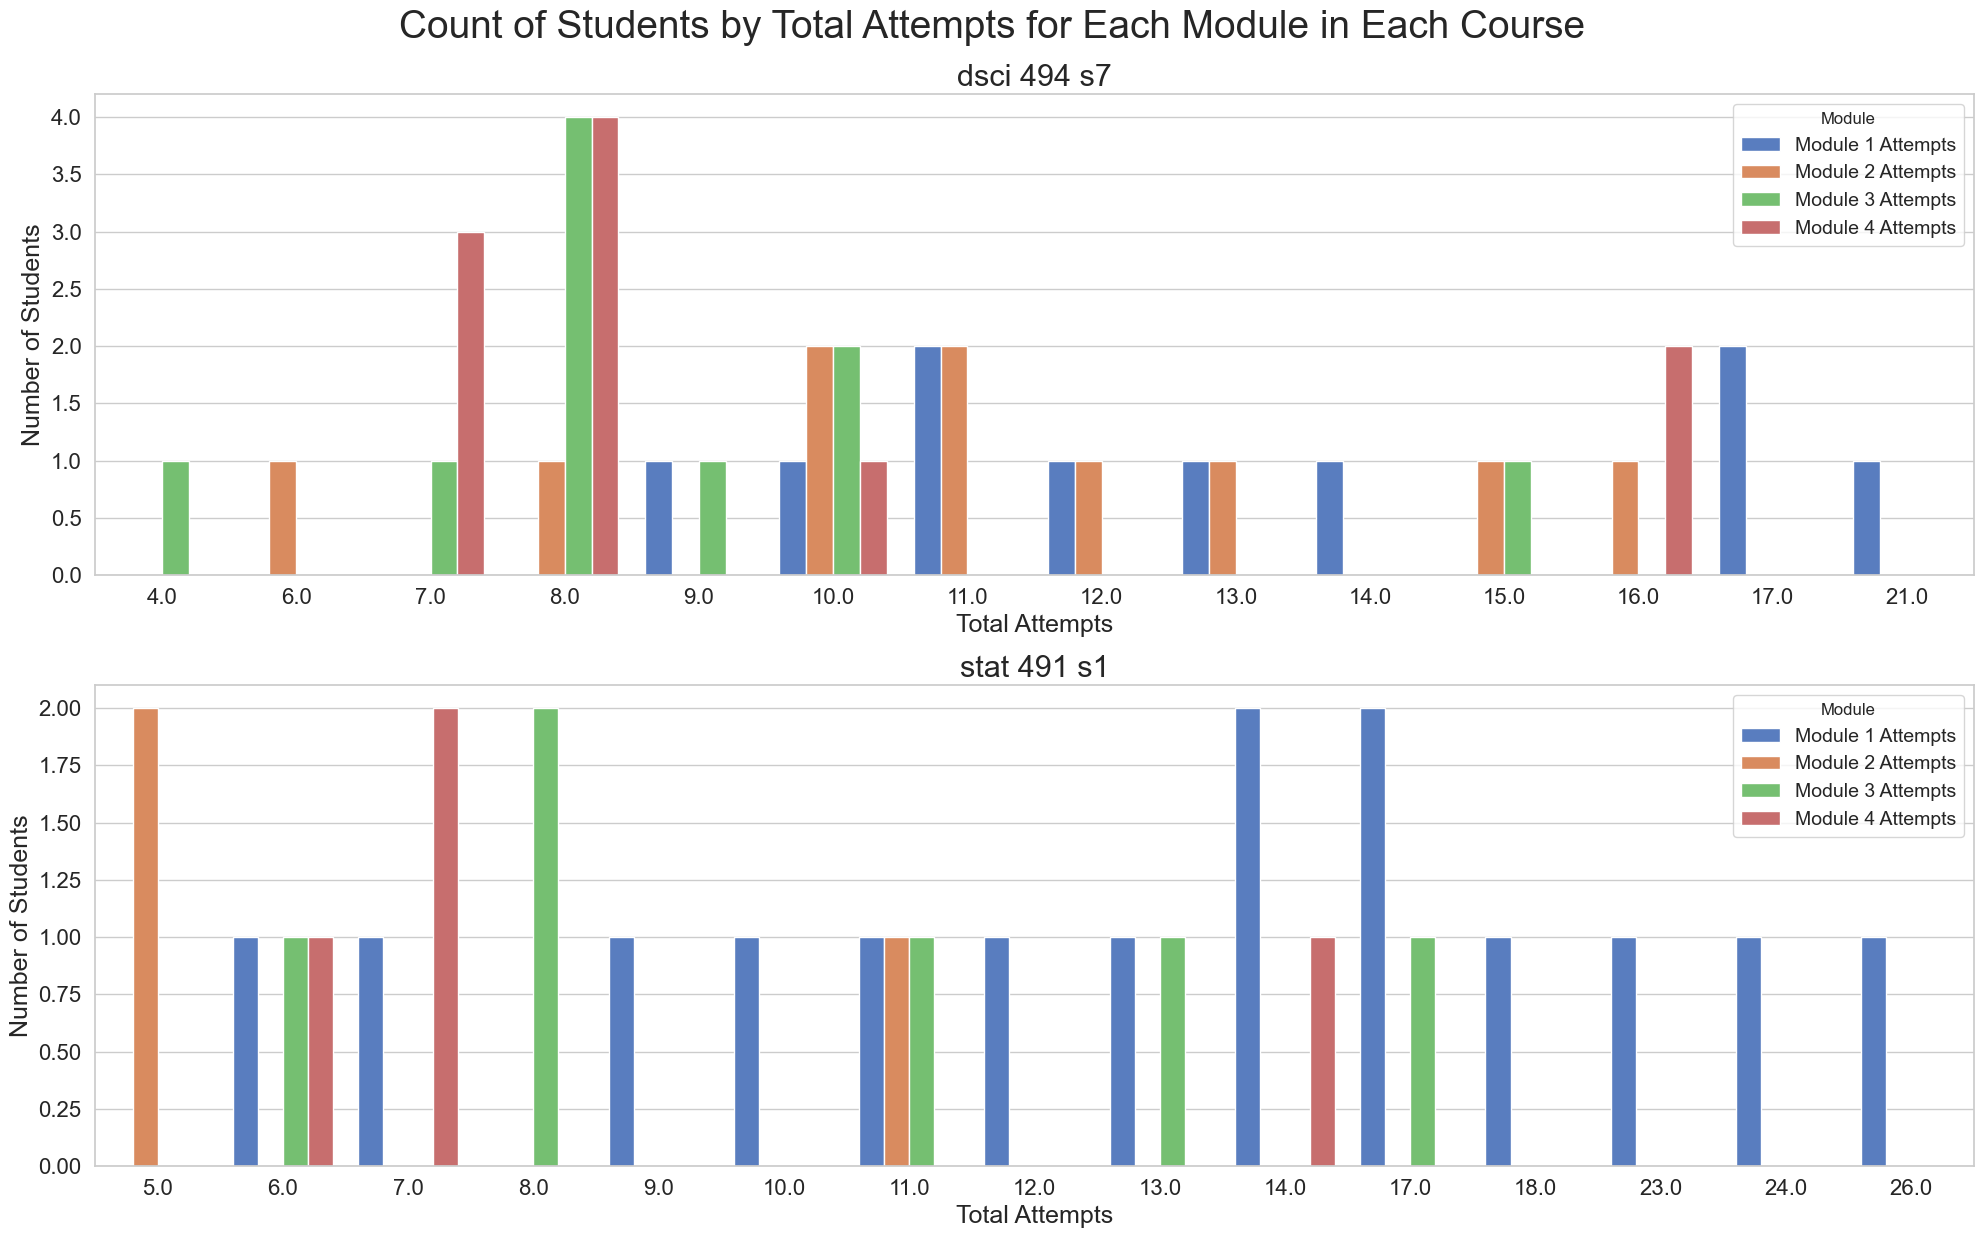

In [126]:
module_palette = sns.color_palette("muted", n_colors=4)
module_palette_dict = {
    'Module 1 Attempts': module_palette[0],
    'Module 2 Attempts': module_palette[1],
    'Module 3 Attempts': module_palette[2],
    'Module 4 Attempts': module_palette[3]
}
module_order = ['Module 1 Attempts', 'Module 2 Attempts', 'Module 3 Attempts', 'Module 4 Attempts']
unpivoted_data_pd = combined_files_quizzes.to_pandas()
sns.set(style="whitegrid")
plt.figure(figsize=(20, 12))
for section_index, section in enumerate(unpivoted_data_pd['Section'].unique()):
    section_data = unpivoted_data_pd[unpivoted_data_pd['Section'] == section]
    program = section_data['Program'].iloc[0] if not section_data.empty else "Unknown Program"
    course = section_data['Course'].iloc[0] if not section_data.empty else "Unknown Course"
    section_data_melted = section_data.melt(
        id_vars=['Program', 'Course', 'Section', 'UserName', 'FirstName', 'LastName'],
        value_vars=module_order,
        var_name='Module',
        value_name='Attempts'
    )
    plt.subplot(len(unpivoted_data_pd['Section'].unique()), 1, section_index + 1)
    sns.countplot(
        data=section_data_melted, x='Attempts', hue='Module', 
        palette=module_palette_dict, hue_order=module_order
    )
    plt.title(f'{program} {course} {section}', fontsize=22)
    plt.xlabel('Total Attempts', fontsize=18)
    plt.ylabel('Number of Students', fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(title="Module", fontsize=14)
plt.tight_layout()
plt.suptitle('Count of Students by Total Attempts for Each Module in Each Course', fontsize=28, y=1.03)
module_attempts = plt.gcf() 
plt.show()

In [127]:
module_attempts.savefig('./results/module_attempts.png', bbox_inches='tight', dpi=72)

### Task 3 - Summarize attendance and practice quiz attempts

Finally, you need to create a overall summary of the attendance and practice quiz attempts.  This table will have one row per course section and include the following summaries.

* `Program` (e.g., `stat`)
* `Course` (e.g., `491`)
* `Section` (e.g., `s1`)
* `Min(Attendance)`
* `Mean(Attendance)`
* `Max(Attendance)`
* `Mean(Module 1 Attempts)`, 
* `Mean(Module 2 Attempts)`, 
* `Mean(Module 3 Attempts)`, 
* `Mean(Module 4 Attempts)`, and 
* `Mean(Total Attempts)`.  

Write this table to a parquet file that is partitioned by program and course number.

### Data Management

#### WET Method:

In [128]:
summarize_attendance_quiz = (combined_files
                             .join(combined_files_quizzes, on=['Program', 'Course', 'Section'], how='left')
                             .group_by(['Program', 'Course', 'Section'])
                             .agg([
                                 pl.col('TotalAttendance').min().alias('Min(Attendance)'),
                                 pl.col('TotalAttendance').mean().alias('Mean(Attendance)'),
                                 pl.col('TotalAttendance').max().alias('Max(Attendance)'),
                                 pl.col('Module 1 Attempts').mean().alias('Mean(Module 1 Attempts)'),
                                 pl.col('Module 2 Attempts').mean().alias('Mean(Module 2 Attempts)'),
                                 pl.col('Module 3 Attempts').mean().alias('Mean(Module 3 Attempts)'),
                                 pl.col('Module 4 Attempts').mean().alias('Mean(Module 4 Attempts)'),
                                 pl.col('Total Attempts').mean().alias('Mean(Total Attempts)')
                             ])
                            )
summarize_attendance_quiz

Program,Course,Section,Min(Attendance),Mean(Attendance),Max(Attendance),Mean(Module 1 Attempts),Mean(Module 2 Attempts),Mean(Module 3 Attempts),Mean(Module 4 Attempts),Mean(Total Attempts)
str,str,str,i64,f64,i64,f64,f64,f64,f64,f64
"""dsci""","""494""","""s7""",14,18.2,19,13.5,11.2,8.7,9.5,42.9
"""stat""","""491""","""s1""",13,17.73913,19,14.733333,7.0,10.5,8.5,45.666667
"""stat""","""180""","""s18""",12,18.066667,20,null,null,null,null,null


#### Now, simplefy by using the DRY Method:

In [129]:
agg_func = lambda func, col: func((col)).alias(f'{func.__name__.capitalize()}({col})')
modules = [f'Module {i} Attempts' for i in range(1, 5)] 

summarize_attendance_quiz_dry = (combined_files
    .join(combined_files_quizzes, on=['Program', 'Course', 'Section'], how='left')
    .group_by(['Program', 'Course', 'Section'])
    .agg([
        agg_func(pl.min, 'TotalAttendance').alias('Min(Attendance)'),
        agg_func(pl.mean, 'TotalAttendance').alias('Mean(Attendance)'),
        agg_func(pl.max, 'TotalAttendance').alias('Max(Attendance)'),
        *[agg_func(pl.mean, module).alias(f'Mean({module})') for module in modules],
        agg_func(pl.mean, 'Total Attempts').alias('Mean(Total Attempts)')])
)
summarize_attendance_quiz_dry

Program,Course,Section,Min(Attendance),Mean(Attendance),Max(Attendance),Mean(Module 1 Attempts),Mean(Module 2 Attempts),Mean(Module 3 Attempts),Mean(Module 4 Attempts),Mean(Total Attempts)
str,str,str,i64,f64,i64,f64,f64,f64,f64,f64
"""dsci""","""494""","""s7""",14,18.2,19,13.5,11.2,8.7,9.5,42.9
"""stat""","""491""","""s1""",13,17.73913,19,14.733333,7.0,10.5,8.5,45.666667
"""stat""","""180""","""s18""",12,18.066667,20,null,null,null,null,null


In [130]:
path = 'results/summarized_attendance_quiz.parquet'
summarize_attendance_quiz_dry.write_parquet(path, partition_by=['Program', 'Course', 'Section'])

### Make a Visualization for the Problem

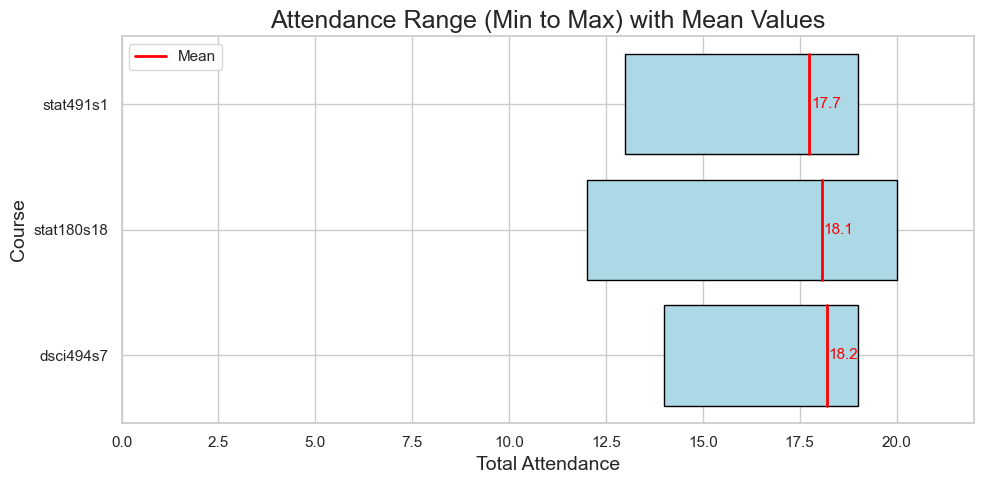

In [131]:
summary_df = summarize_attendance_quiz_dry.to_pandas()
sns.set(style="whitegrid")
plt.figure(figsize=(10, 5))
plt.subplot(1, 1, 1)  
attendance_stats = summary_df.groupby(['Program', 'Course', 'Section']).agg({
    'Min(Attendance)': 'mean',
    'Mean(Attendance)': 'mean',
    'Max(Attendance)': 'mean'}).reset_index()
attendance_stats['ProgramCourseSection'] = attendance_stats['Program'] + attendance_stats['Course'] + attendance_stats['Section']
for index, row in attendance_stats.iterrows():
    bar_left = row['Min(Attendance)']
    bar_width = row['Max(Attendance)'] - bar_left
    plt.barh(row['ProgramCourseSection'], bar_width, left=bar_left, color='lightblue', edgecolor='black')
    plt.plot([row['Mean(Attendance)'], row['Mean(Attendance)']], 
             [index - 0.4, index + 0.4], color='red', linestyle='-', linewidth=2) 
    plt.text(row['Mean(Attendance)'] + 0.05, index,  
             f"{row['Mean(Attendance)']:.1f}", color='red', fontsize=11, verticalalignment='center')
plt.title('Attendance Range (Min to Max) with Mean Values', fontsize=18)
plt.xlabel('Total Attendance', fontsize=14)
plt.ylabel('Course', fontsize=14)
plt.xlim(0, attendance_stats['Max(Attendance)'].max() * 1.1) 
plt.legend(['Mean'], loc='upper left')
plt.tight_layout()
attendance_range = plt.gcf()
plt.show()

In [132]:
attendance_range.savefig('./results/attendance_range.png', dpi=72)

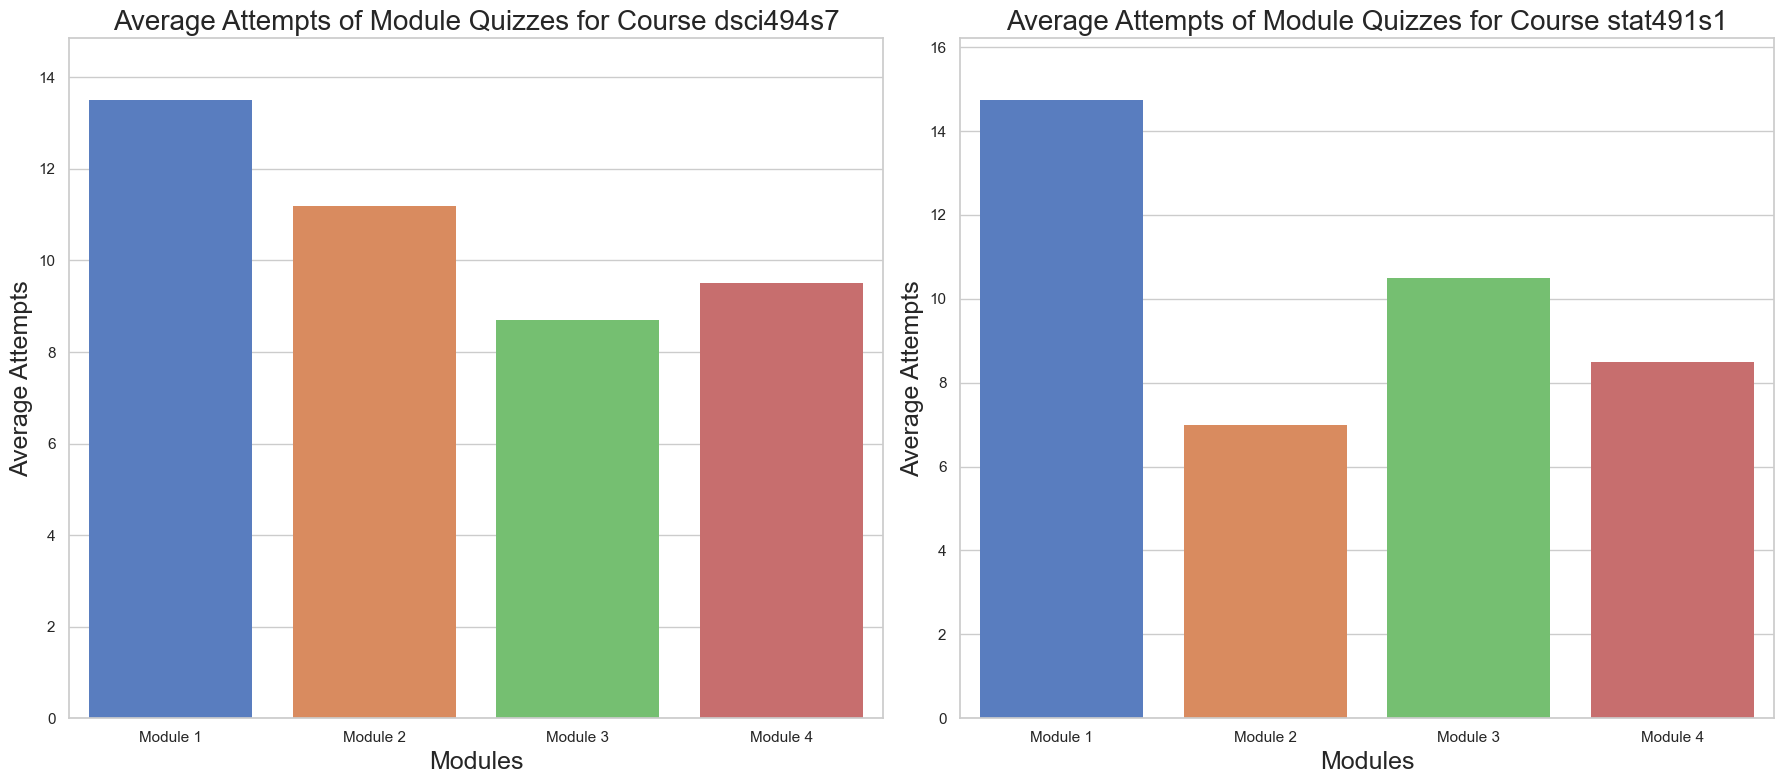

In [133]:
filtered_sections = ['s1', 's7']
filtered_df = summarize_attendance_quiz_dry.filter(summarize_attendance_quiz_dry['Section'].is_in(filtered_sections)).to_pandas()
sns.set(style="whitegrid")
sections = filtered_df['Section'].unique()
plt.figure(figsize=(18, 8)) 
for i, section in enumerate(sections):
    section_data = filtered_df[filtered_df['Section'] == section]
    program = section_data['Program'].iloc[0] if not section_data.empty else "Unknown Program"
    course = section_data['Course'].iloc[0] if not section_data.empty else "Unknown Course"
    module_means = section_data[['Mean(Module 1 Attempts)', 'Mean(Module 2 Attempts)','Mean(Module 3 Attempts)', 'Mean(Module 4 Attempts)']].values.flatten()
    module_labels = ['Module 1', 'Module 2', 'Module 3', 'Module 4']
    plt.subplot(1, len(sections), i + 1)  
    sns.barplot(x=module_labels, y=module_means, hue=module_labels, palette='muted', edgecolor='none', legend=False)
    plt.title(f'Average Attempts of Module Quizzes for Course {program}{course}{section}', fontsize=20) 
    plt.xlabel('Modules', fontsize=18) 
    plt.ylabel('Average Attempts', fontsize=18)  
    plt.ylim(0, max(module_means) * 1.1)  
plt.tight_layout()
average_module_attempts = plt.gcf()
plt.show()

In [134]:
average_module_attempts.savefig('./results/average_module_attempts.png', dpi=72)

## Deliverables

1. You should commit and push your work in this notebook along with each of the files from the last three tasks.  
2. Submit a WORD doc on D2L containing a link to your repository and screenshots of your code for each part.